# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Muhammad Azka Ananta Khairon| 5054251004|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

data = pd.read_csv("/content/diabetes.csv")
print("Jumlah baris dan kolom:", df.shape)
data.head()

Jumlah baris dan kolom: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [ ]:
data.info()
print("Jumlah baris duplikat:", data.duplicated().sum())
print("Jumlah baris kosong:")
data.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
Jumlah baris duplikat: 0
Jumlah baris kosong:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


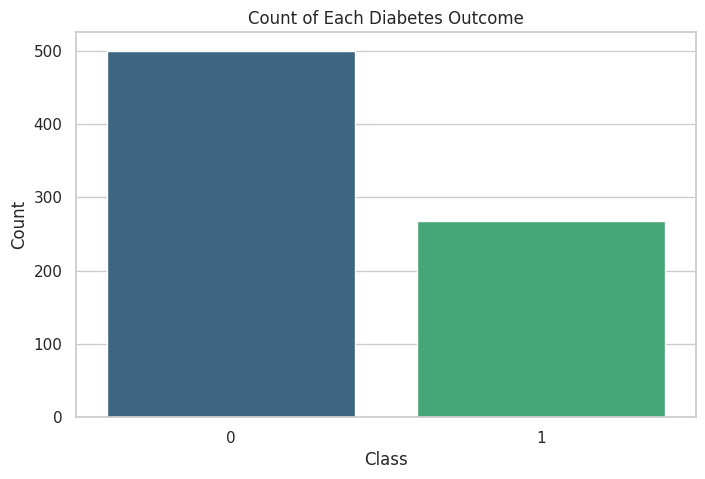

In [ ]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

plt.figure(figsize=(8, 5))
sns.countplot(x='Outcome', hue='Outcome', data=data, palette='viridis', legend=False)
plt.title('Count of Each Diabetes Outcome')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

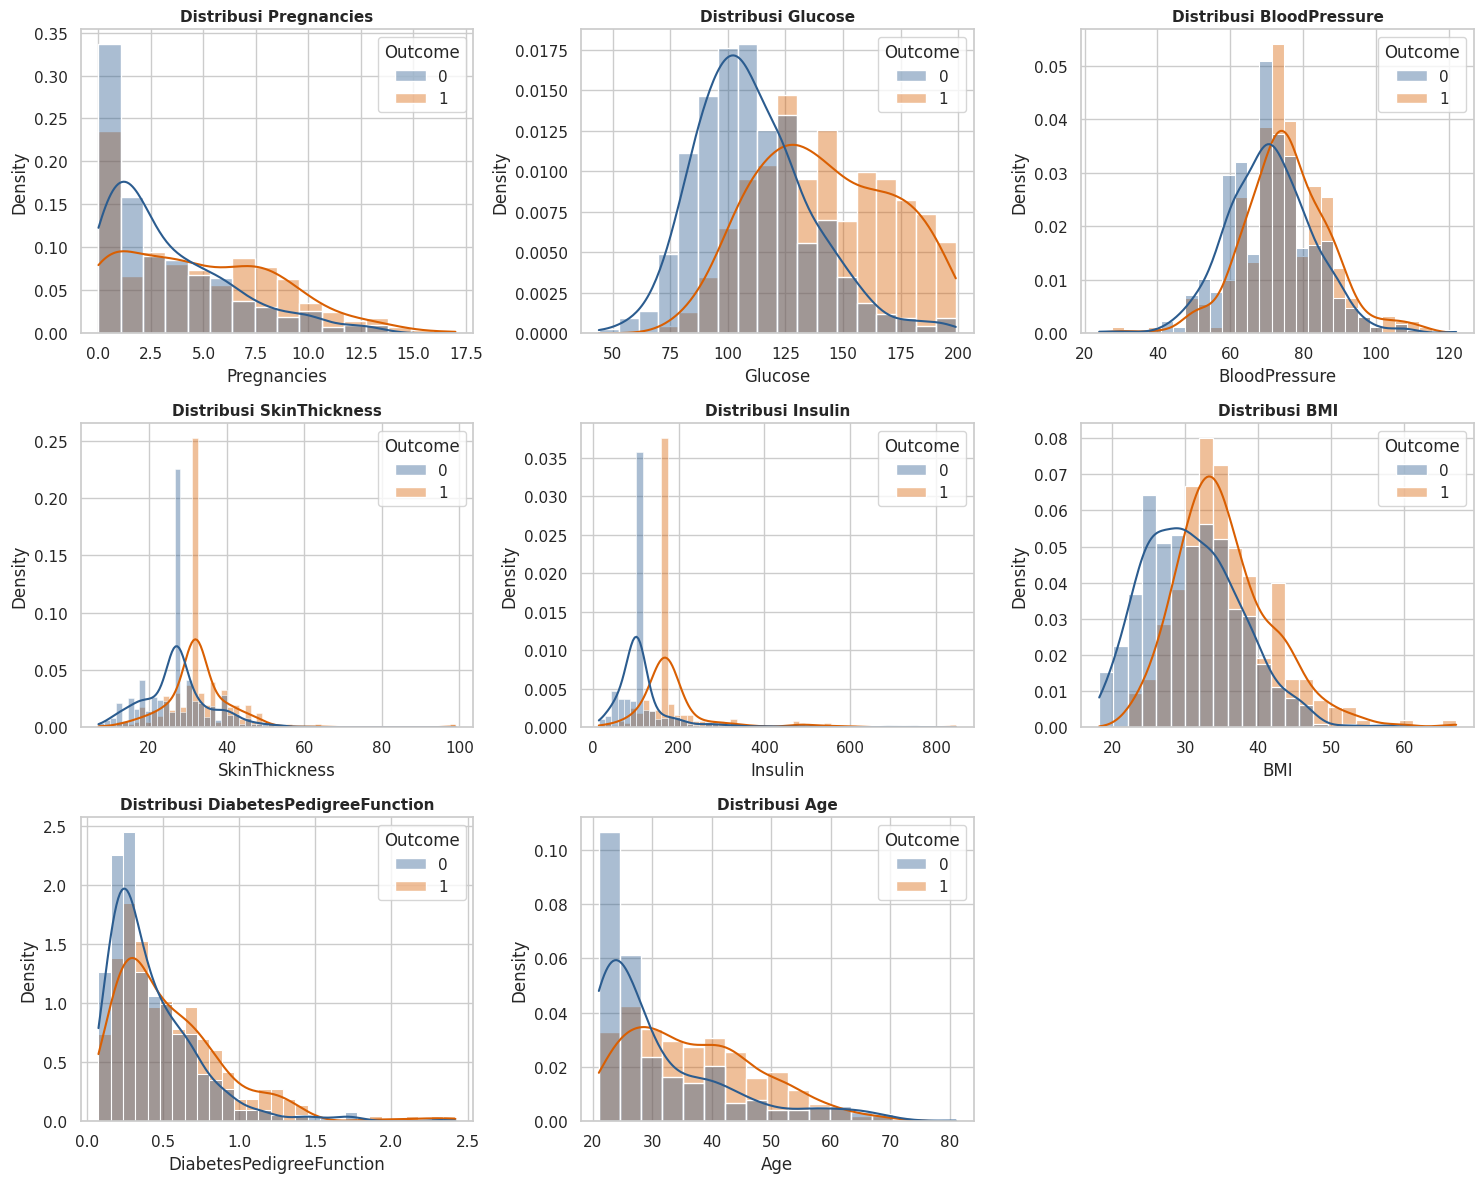

In [ ]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.

sns.set_theme(style="whitegrid")

features = [col for col in data.columns if col != "Outcome"]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
  sns.histplot(
      data=data,
      x=col,
      hue='Outcome',
      kde=True,
      stat='density',
      common_norm=False,
      palette={0: '#2b5c8f', 1: '#d95f02'},
      alpha=0.4,
      ax=axes[i],
  )
  axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Density')

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

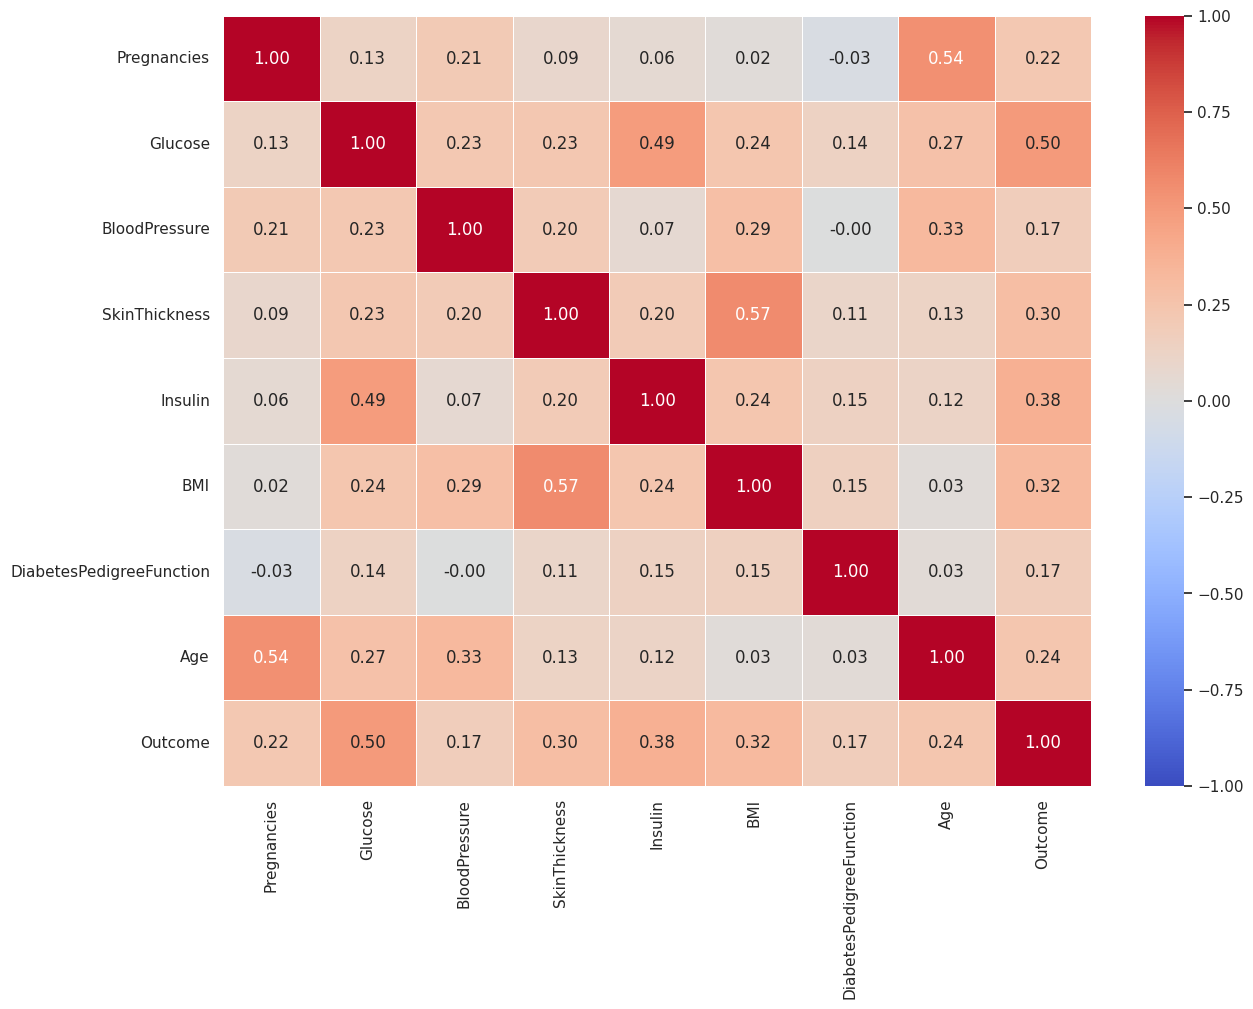

In [ ]:
# Tampilkan heatmap korelasi antar fitur.

plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(), cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, annot=True, fmt=".2f")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

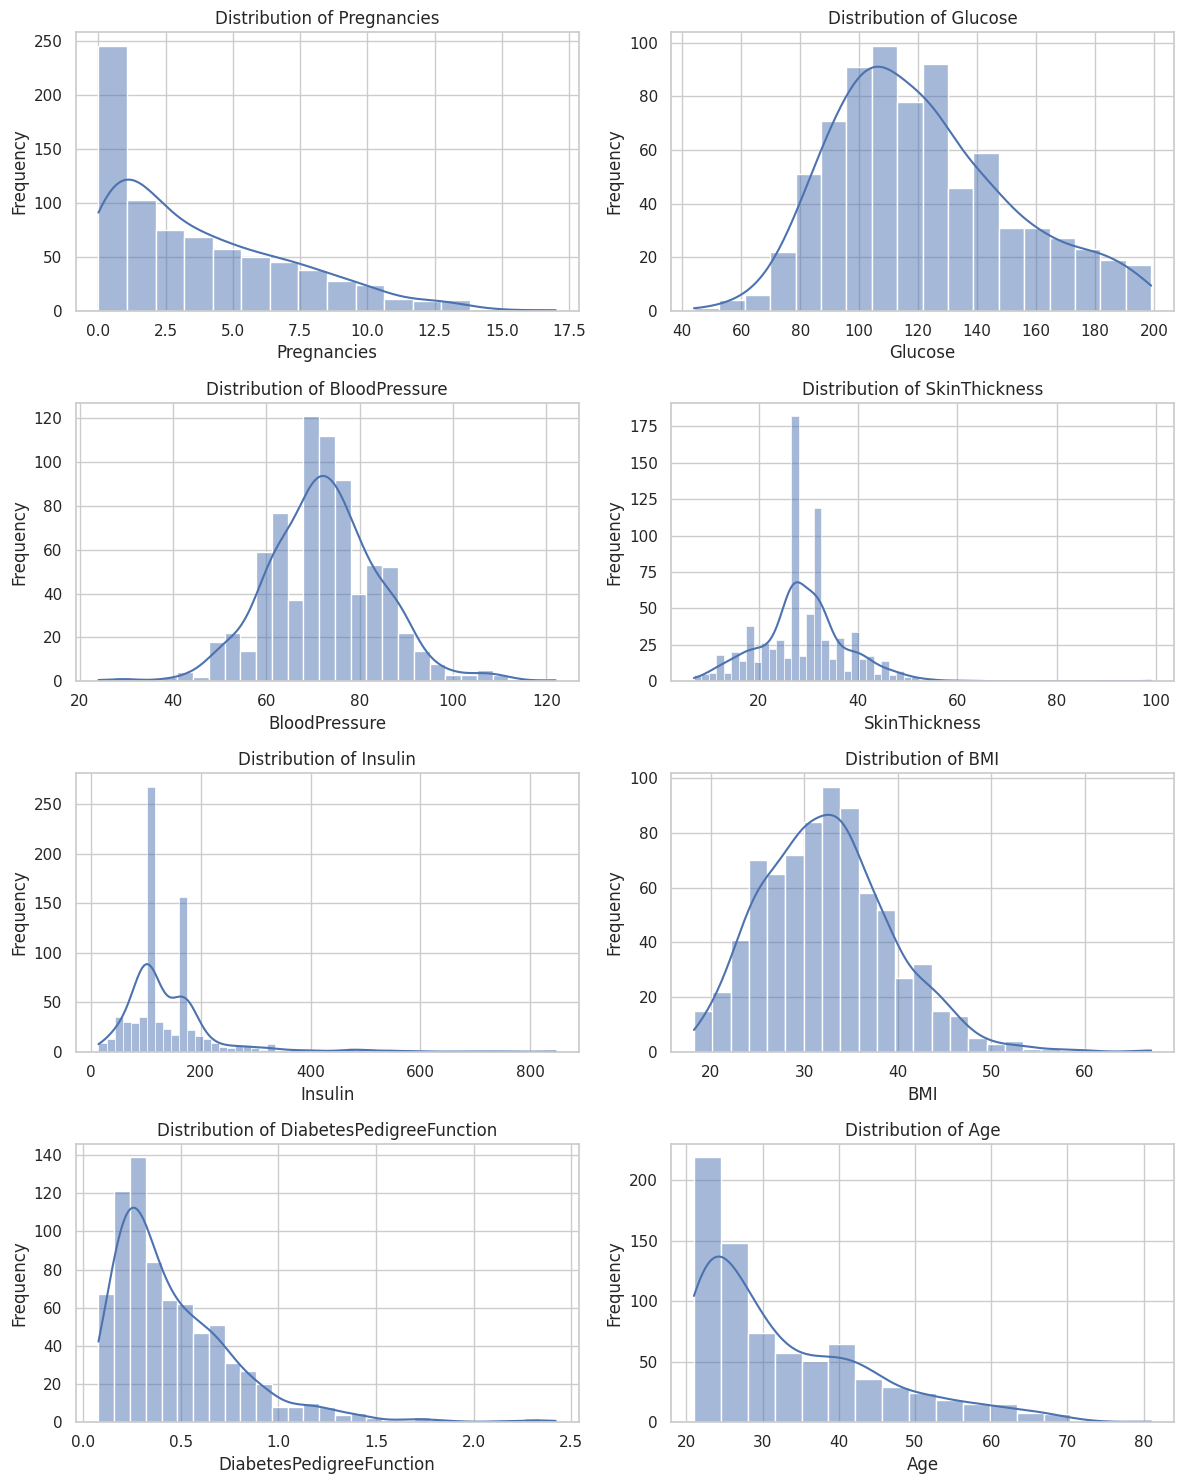

In [ ]:
plt.figure(figsize=(12, 15))
for i, col in enumerate(features):
  plt.subplot(4, 2, i + 1)
  sns.histplot(data[col], kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

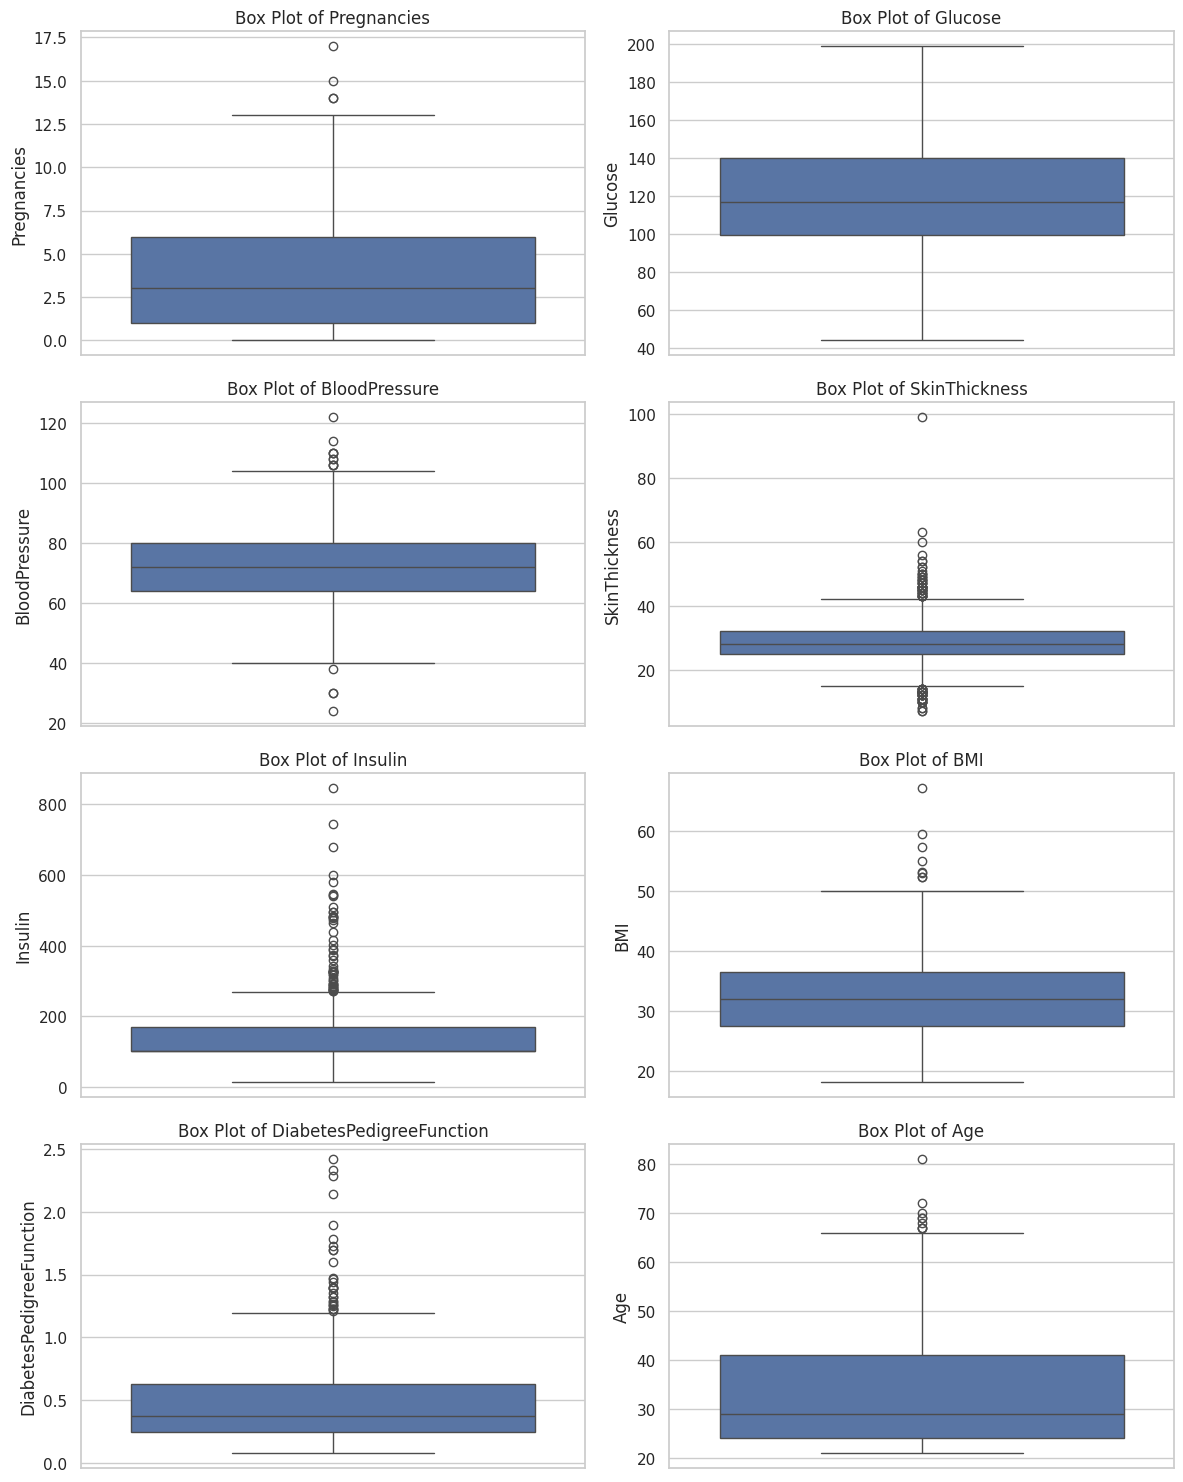

In [ ]:
plt.figure(figsize=(12, 15))
for i, col in enumerate(features):
  plt.subplot(4, 2, i + 1)
  sns.boxplot(y=data[col])
  plt.title(f'Box Plot of {col}')
  plt.ylabel(col)
plt.tight_layout()
plt.show()

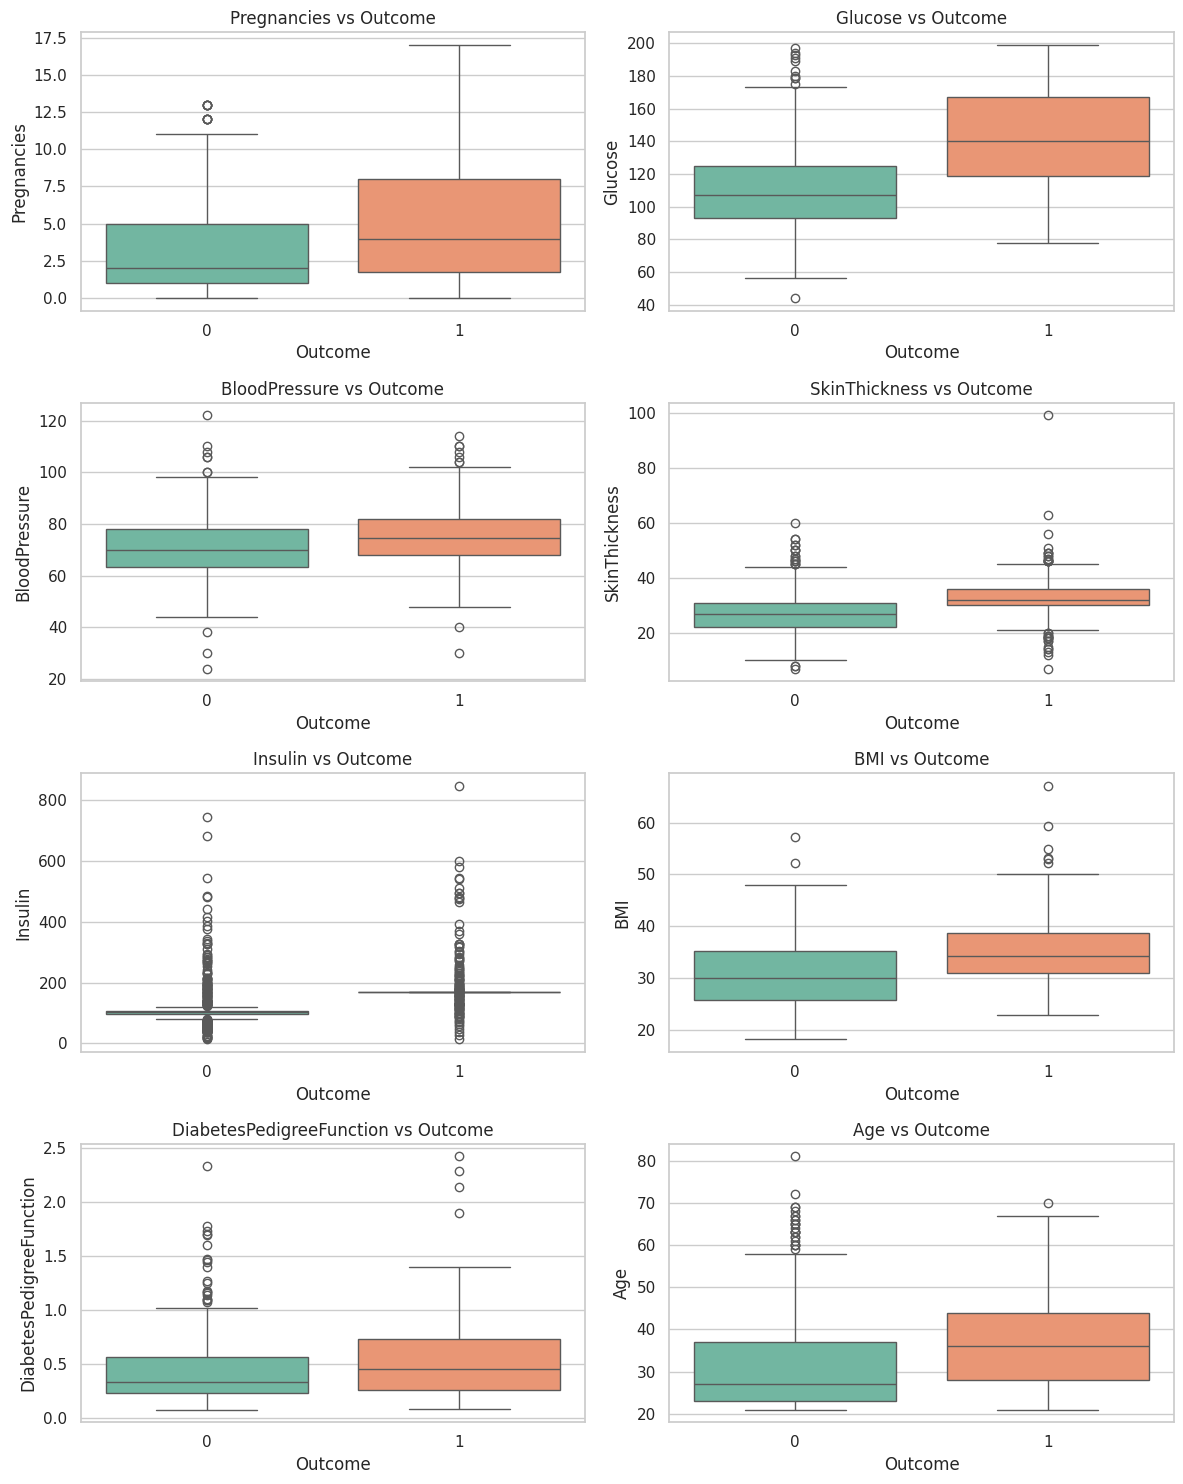

In [ ]:
plt.figure(figsize=(12, 15))
for i, col in enumerate(features):
  plt.subplot(4, 2, i + 1)
  sns.boxplot(data=data, x="Outcome", y=col, hue="Outcome", palette="Set2", legend=False)
  plt.title(f"{col} vs Outcome")
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [ ]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.

zero_counts = (df[features] == 0).sum()
zero_percentages = (df[features] == 0).mean() * 100

zero_summary = pd.DataFrame({'Jumlah Nilai 0': zero_counts, 'Persentase (%)': zero_percentages.round(2)})
zero_summary

,Jumlah Nilai 0,Persentase (%)
Pregnancies,111,14.45
Glucose,0,0.00
BloodPressure,0,0.00
SkinThickness,0,0.00
Insulin,0,0.00
BMI,0,0.00
DiabetesPedigreeFunction,0,0.00
Age,0,0.00


In [ ]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

In [ ]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = data.drop(columns=['Outcome'])
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Ukuran data train:", X_train.shape)

Ukuran data train: (614, 8)


In [ ]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [ ]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.

gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [ ]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.

logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_logreg = logreg_model.predict(X_test_scaled)
y_prob_logreg = logreg_model.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.

metrics_data = {
    'Model': ['Gaussian NB', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_logreg)
    ],
    'Precision': [
        precision_score(y_test, y_pred_gnb, pos_label=1),
        precision_score(y_test, y_pred_logreg, pos_label=1)
    ],
    'Recall': [
        recall_score(y_test, y_pred_gnb, pos_label=1),
        recall_score(y_test, y_pred_logreg, pos_label=1)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_gnb, pos_label=1),
        f1_score(y_test, y_pred_logreg, pos_label=1)
    ]
}

df_comparison = pd.DataFrame(metrics_data)
df_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian NB,0.727273,0.603448,0.648148,0.625000
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429


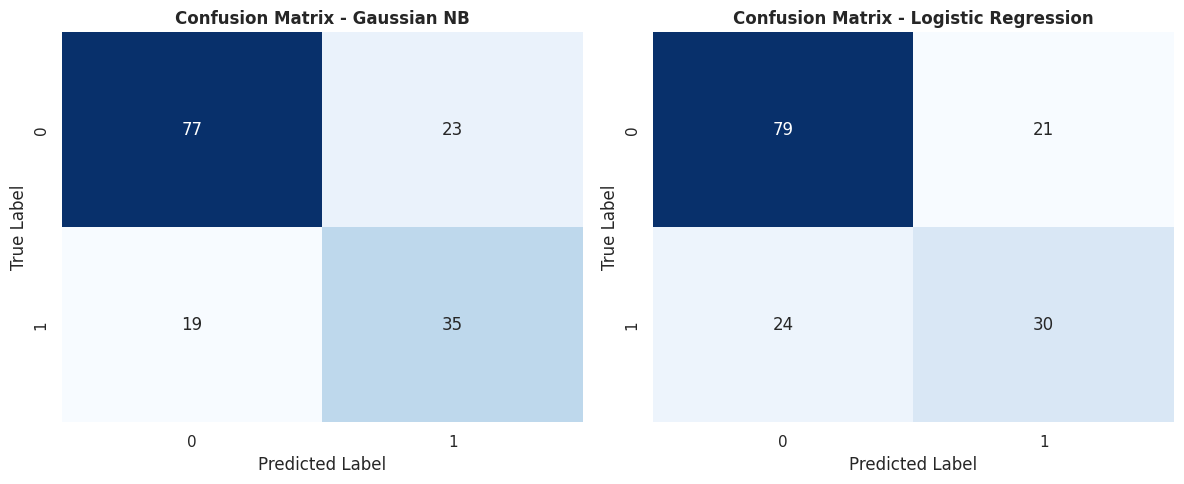

In [ ]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [
    ('Gaussian NB', y_pred_gnb, axes[0]),
    ('Logistic Regression', y_pred_logreg, axes[1])
]

for title, y_pred, ax in models:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

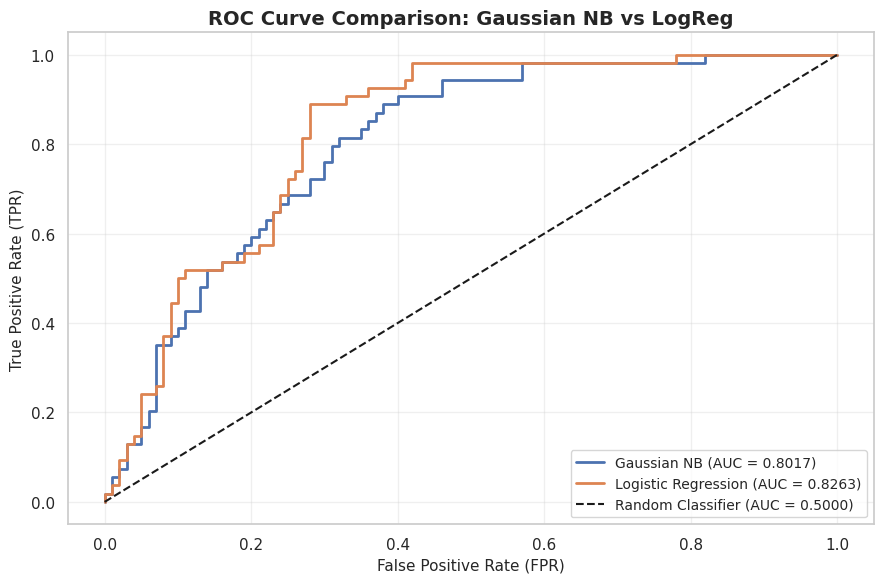

In [ ]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.

fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
auc_gnb = roc_auc_score(y_test, y_prob_gnb)

fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
auc_logreg = roc_auc_score(y_test, y_prob_logreg)

plt.figure(figsize=(9, 6))

plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian NB (AUC = {auc_gnb:.4f})', linewidth=2)
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)')

plt.title('ROC Curve Comparison: Gaussian NB vs LogReg', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

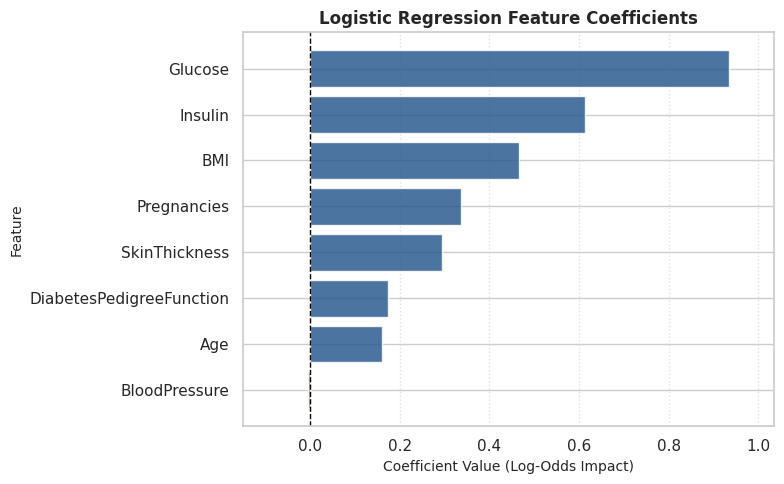

In [ ]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': logreg_model.coef_[0]}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8, 5))

colors = ['#2b5c8f' if c > 0 else '#d95f02' for c in coef_df['Coefficient']]

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.title('Logistic Regression Feature Coefficients', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Log-Odds Impact)', fontsize=10)
plt.ylabel('Feature', fontsize=10)
plt.xlim(-0.15, max(coef_df['Coefficient']) + 0.1)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 5. Analisis

### Berdasarkan hasil eksperimen klasifikasi pada Pima Indians Diabetes Dataset, kedua model menunjukkan performa yang cukup baik dalam membedakan pasien positif dan negatif diabetes. Hal ini dibuktikan oleh nilai AUC dari kedua model yang berada di atas 0.80.
### Meskipun kedua model menghasilkan skor akurasi yang cukup berimbang pada kisaran 70%–72%, terdapat perbedaan karakteristik performa dari masing-masing algoritma:
###1. Gaussian Naive Bayes mencatatkan akurasi sebesar 72.73% dengan nilai AUC 0.8017. Dari total 154 data uji, model ini menghasilkan 42 kesalahan prediksi (77 True Negative, 35 True Positive, 23 False Positive, dan 19 False Negative). Tingginya nilai Recall (64.81%) pada GNB terjadi karena model mengasumsikan independensi serta distribusi Gaussian pada fitur numerik, yang mana cukup efektif menangkap pola pemisahan pada variabel medis utama seperti Glucose dan BMI.
###2. Logistic Regression mencatatkan akurasi sebesar 70.78% dengan nilai AUC yang lebih tinggi sebesar 0.8263, namun menghasilkan total 45 kesalahan prediksi (79 True Negative, 30 True Positive, 21 False Positive, dan 24 False Negative). Keunggulan nilai AUC pada Logistic Regression disebabkan oleh kemampuan model dalam menghasilkan estimasi probabilitas yang lebih terkalibrasi secara linier melalui fungsi sigmoid, meskipun pada threshold default (0.5) jumlah kesalahan False Negative yang dihasilkan lebih banyak (24 sampel).

# 6. Kesimpulan dan Saran

### Dari sudut pandang medis, kesalahan False Negative (pasien penderita diabetes yang salah diprediksi sebagai non-diabetes) memiliki dampak yang lebih fatal karena dapat berujung pada keterlambatan penanganan medis. Meskipun Gaussian Naive Bayes berhasil menekan nilai False Negative hingga 19 sampel (lebih baik dibanding Logistic Regression yang mencapai 24 sampel), tingkat sensitivitas tersebut masih perlu ditingkatkan agar lebih aman untuk penerapan di dunia nyata. Untuk pengembangan selanjutnya, disarankan melakukan penyesuaian decision threshold (menurunkan threshold dari 0.5) pada Logistic Regression guna memanfaatkan stabilitas probabilitasnya (AUC 0.8263) sekaligus mendulang Recall yang lebih optimal.